<a href="https://colab.research.google.com/github/ARPRAHMAN/Banking-Stock-Price-Prediction-in-DSE/blob/main/Eastern_Bank_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Adjust the path to your file location
file_path = '/content/drive/MyDrive/0Thesis Dataset/ebl/EBL.csv'
df = pd.read_csv(file_path)
df.head(10)

,Name,Date,Open,High,Low,Close,Volume
0,EBL,29-08-2010,73.0,73.0,69.9,70.0,392800
1,EBL,30-08-2010,70.0,70.6,66.0,67.0,334200
2,EBL,31-08-2010,65.5,70.0,65.0,67.4,363400
3,EBL,02-09-2010,69.4,70.0,68.9,69.4,597000
4,EBL,05-09-2010,70.9,71.0,69.9,70.5,379200
5,EBL,06-09-2010,70.9,70.9,69.0,69.9,533400
6,EBL,08-09-2010,71.0,71.9,69.9,71.6,639200
7,EBL,13-09-2010,73.4,73.4,71.1,72.1,588400
8,EBL,14-09-2010,70.2,72.0,70.2,70.9,621800
9,EBL,15-09-2010,71.3,71.3,69.3,70.0,534400


In [ ]:
# Check null value count per column
print("Null value count in raw dataset (df):")
print(df.isnull().sum())

Null value count in raw dataset (df):
Name      0
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [ ]:
# Drop rows that are completely null
df = df.dropna(how='all')

# Verify
print(df.isnull().sum())


Name      0
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


**Check few thing and change it:**

1.   Remove Name column
2.   Date sortation format (dd-mm-yyyy)



In [ ]:
import pandas as pd

# Create new dataset from raw df
dataset = df.copy()

# Convert date and sort
dataset['Date_dt'] = pd.to_datetime(
    dataset['Date'],
    format='%d-%m-%Y'
)

dataset = dataset.sort_values('Date_dt').reset_index(drop=True)

# Drop helper and unnecessary columns
dataset = dataset.drop(columns=['Date_dt'])
dataset = dataset.drop(columns=['Name'])
# Save clean dataset
dataset.to_csv(
    "/content/drive/MyDrive/0Thesis Dataset/ebl/EBL_Clean.csv",
    index=False
)

print("Dataset sorted, 'Name' column removed, and saved as EBL_clean.csv")


Dataset sorted, 'Name' column removed, and saved as EBL_clean.csv


In [ ]:
dataset.head()

,Date,Open,High,Low,Close,Volume
0,29-08-2010,73.0,73.0,69.9,70.0,392800
1,30-08-2010,70.0,70.6,66.0,67.0,334200
2,31-08-2010,65.5,70.0,65.0,67.4,363400
3,02-09-2010,69.4,70.0,68.9,69.4,597000
4,05-09-2010,70.9,71.0,69.9,70.5,379200


**Chart**

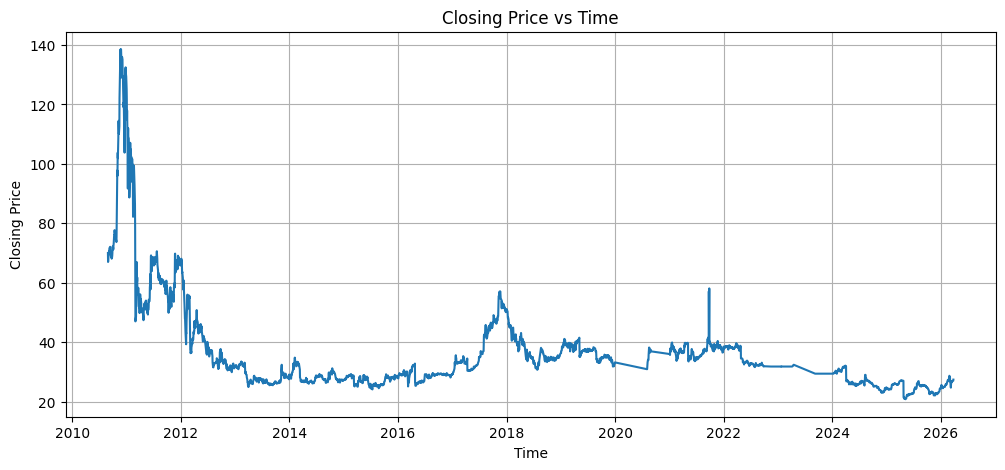

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "/content/drive/MyDrive/0Thesis Dataset/ebl/EBL_Clean.csv"
)

# Convert Date to datetime (safe)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Plot Closing Price vs Time
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'])
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.title("Closing Price vs Time")
plt.grid(True)
plt.show()


In [ ]:
print(dataset.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


*## Correlation check before add new or more features*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# DEFINE TARGET
# ================================
dataset['Target_Close'] = dataset['Close'].shift(-1)

# Drop only last row (no future target)
corr_df = dataset.dropna().reset_index(drop=True)

# ================================
# BASE FEATURES
# ================================
base_features = ['Open', 'High', 'Low', 'Close', 'Volume']

# ================================
# CORRELATION WITH TARGET
# ================================
corr = corr_df[base_features + ['Target_Close']].corr()
target_corr = corr['Target_Close'].drop('Target_Close')

print("Correlation with Target_Close:\n")
print(target_corr.sort_values(ascending=False))


Correlation with Target_Close:

Close     0.995349
High      0.992532
Low       0.991772
Open      0.990187
Volume    0.126618
Name: Target_Close, dtype: float64


**Diagram for better visual**

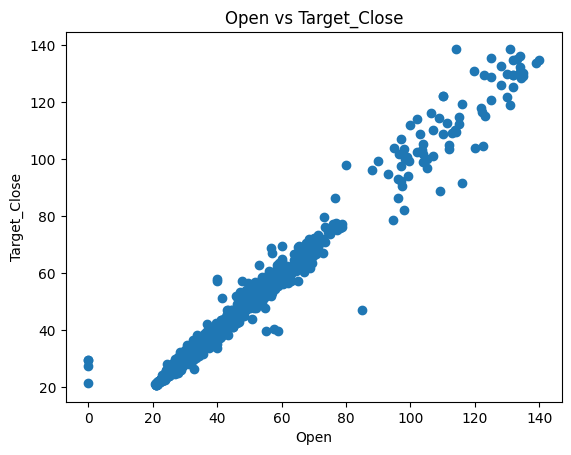

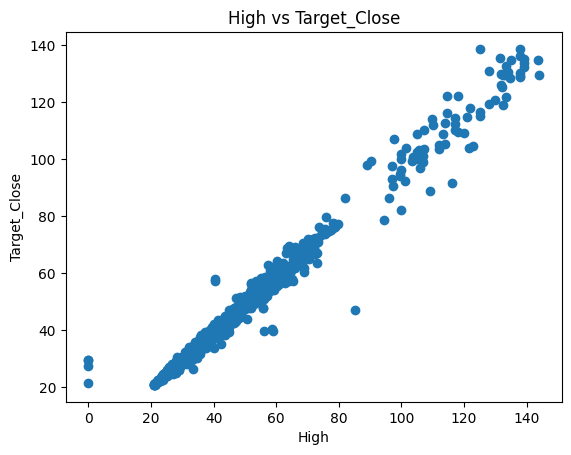

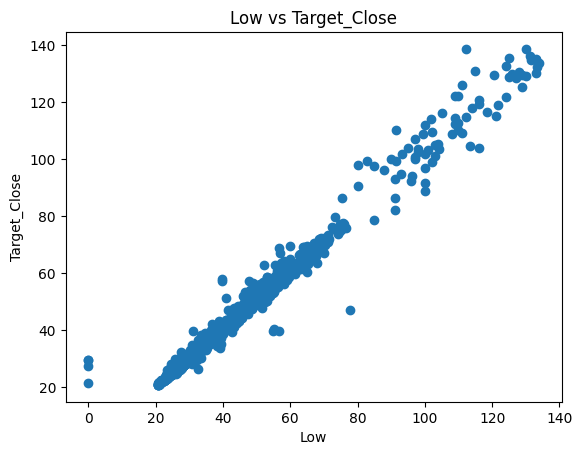

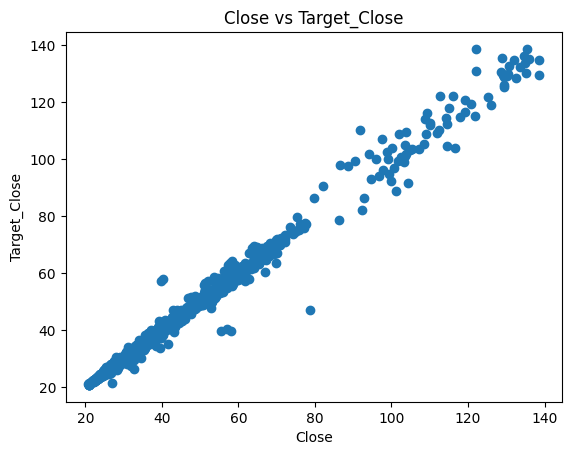

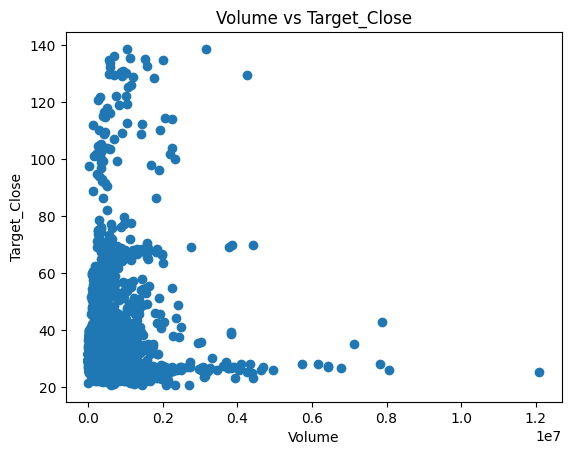

In [ ]:
# ================================
# SCATTER DIAGRAMS
# ================================
for feature in base_features:
    plt.figure()
    plt.scatter(corr_df[feature], corr_df['Target_Close'])
    plt.xlabel(feature)
    plt.ylabel("Target_Close")
    plt.title(f"{feature} vs Target_Close")
    plt.show()

***Add new and more features which is showing some patterns with target features***

In [ ]:
# ================================
#  CREATE FINAL DATASET COPY
# ================================
df_final = dataset.copy()

# ================================
# PRICE-BASED FEATURES
# ================================
df_final['price_change'] = df_final['Close'] - df_final['Close'].shift(1)
df_final['log_return'] = np.log(df_final['Close'] / df_final['Close'].shift(1))
df_final['daily_range'] = df_final['High'] - df_final['Low']
df_final['typical_price'] = (
    df_final['High'] + df_final['Low'] + df_final['Close']
) / 3

# ================================
# VOLUME FEATURES
# ================================
df_final['volume_change'] = df_final['Volume'].pct_change(fill_method=None)

# ================================
#  TREND INDICATORS
# ================================
df_final['SMA_10'] = df_final['Close'].rolling(10).mean()
df_final['SMA_20'] = df_final['Close'].rolling(20).mean()

df_final['EMA_10'] = df_final['Close'].ewm(span=10, adjust=False).mean()
df_final['EMA_20'] = df_final['Close'].ewm(span=20, adjust=False).mean()

# ================================
#  MACD
# ================================
ema12 = df_final['Close'].ewm(span=12, adjust=False).mean()
ema26 = df_final['Close'].ewm(span=26, adjust=False).mean()

df_final['MACD'] = ema12 - ema26
df_final['MACD_signal'] = df_final['MACD'].ewm(span=9, adjust=False).mean()

# ================================
#  RSI (14)
# ================================
delta = df_final['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df_final['RSI_14'] = 100 - (100 / (1 + rs))

# ================================
#  BOLLINGER BANDS
# ================================
bb_middle = df_final['Close'].rolling(20).mean()
bb_std = df_final['Close'].rolling(20).std()

df_final['BB_middle'] = bb_middle
df_final['BB_upper'] = bb_middle + 2 * bb_std
df_final['BB_lower'] = bb_middle - 2 * bb_std
df_final['BB_width'] = (df_final['BB_upper'] - df_final['BB_lower']) / bb_middle

# ================================
#  VOLATILITY / RISK
# ================================
df_final['rolling_std_14'] = df_final['log_return'].rolling(14).std()

# ================================
#  TARGET (NEXT-DAY CLOSE)
# ================================
df_final['Target_Close'] = df_final['Close'].shift(-1)

# ================================
#  CLEAN FINAL DATASET
# ================================
df_final = df_final.dropna().reset_index(drop=True)

# ================================
#  SAVE FINAL FEATURE DATASET
# ================================
df_final.to_csv(
    "/content/drive/MyDrive/0Thesis Dataset/ebl/Feature-added-EBL.csv",
    index=False,
    lineterminator="\r\n"
)

print("Final feature dataset created successfully")
print("Saved as: Feature-added-EBL.csv")


Final feature dataset created successfully
Saved as: Feature-added-EBL.csv


In [ ]:
df_final.head()

,Date,Open,High,Low,Close,Volume,Target_Close,price_change,log_return,daily_range,...,EMA_10,EMA_20,MACD,MACD_signal,RSI_14,BB_middle,BB_upper,BB_lower,BB_width,rolling_std_14
0,29-09-2010,71.2,72.3,69.2,72.0,576400,72.2,2.0,0.028171,3.1,...,69.769824,69.695648,0.018155,-0.140254,59.633028,69.580,72.347176,66.812824,0.079539,0.013863
1,30-09-2010,72.9,73.2,71.5,72.2,1124400,71.9,0.2,0.002774,1.7,...,70.211674,69.934158,0.214006,-0.069402,53.191489,69.690,72.692385,66.687615,0.086164,0.012361
2,03-10-2010,72.8,72.8,70.8,71.9,227800,71.2,-0.3,-0.004164,2.0,...,70.518642,70.121381,0.341081,0.012695,48.913043,69.935,72.810138,67.059862,0.082223,0.012278
3,04-10-2010,70.1,72.9,70.1,71.2,276800,72.2,-0.7,-0.009783,2.8,...,70.642525,70.224107,0.380913,0.086338,51.724138,70.125,72.789286,67.460714,0.075987,0.011679
4,05-10-2010,71.3,74.3,71.3,72.2,553000,73.4,1.0,0.013947,3.0,...,70.925703,70.412287,0.487551,0.166581,62.500000,70.265,73.059939,67.470061,0.079554,0.011560


**Now check correlation with all the features (newly added also)**

In [ ]:
# ================================
# CORRELATION WITH TARGET
# ================================
corr = df_final.corr(numeric_only=True)

target_corr = corr['Target_Close'].drop('Target_Close')

# Sort by absolute importance
target_corr = target_corr.sort_values(key=abs, ascending=False)

print("Correlation with Target_Close:\n")
print(target_corr)


Correlation with Target_Close:

Close             0.995215
typical_price     0.994291
High              0.992847
Low               0.992119
Open              0.990454
EMA_10            0.987032
SMA_10            0.984017
EMA_20            0.975665
SMA_20            0.969671
BB_middle         0.969671
BB_upper          0.956529
BB_lower          0.942159
daily_range       0.757134
BB_width          0.438561
rolling_std_14    0.377674
MACD_signal       0.276158
MACD              0.253289
Volume            0.120745
RSI_14            0.072009
price_change      0.036336
log_return        0.028267
volume_change    -0.008618
Name: Target_Close, dtype: float64


**Diagram**

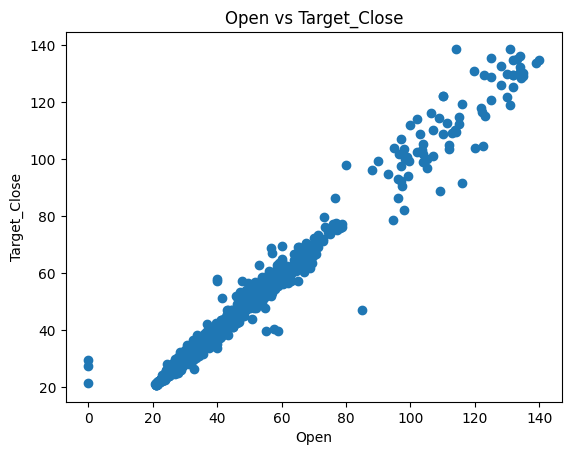

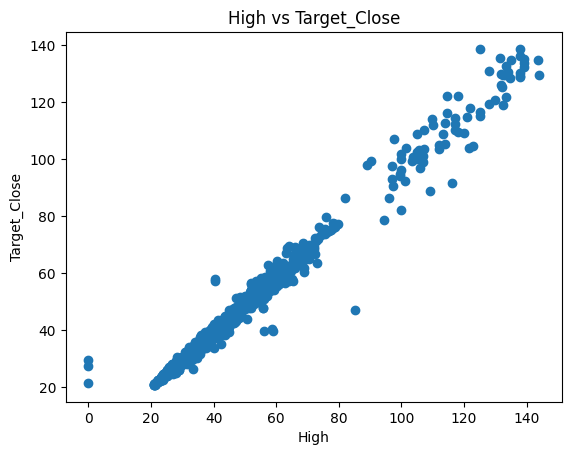

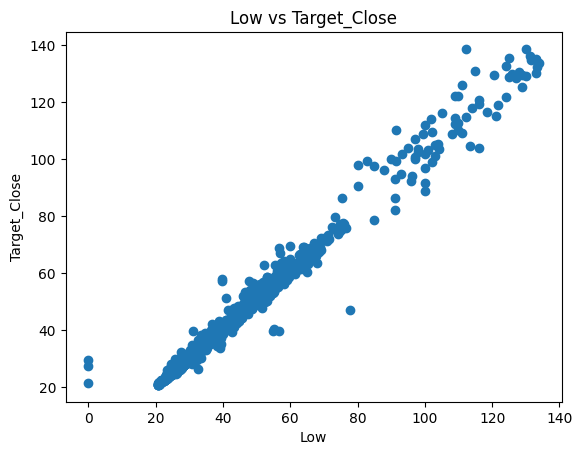

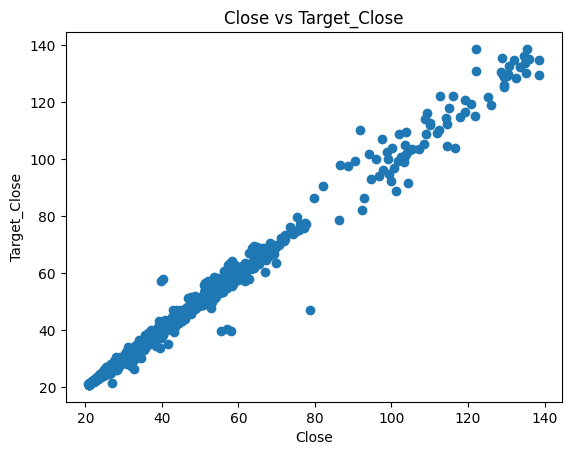

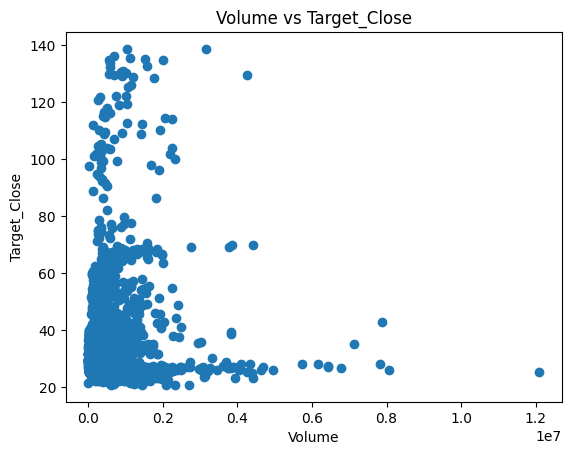

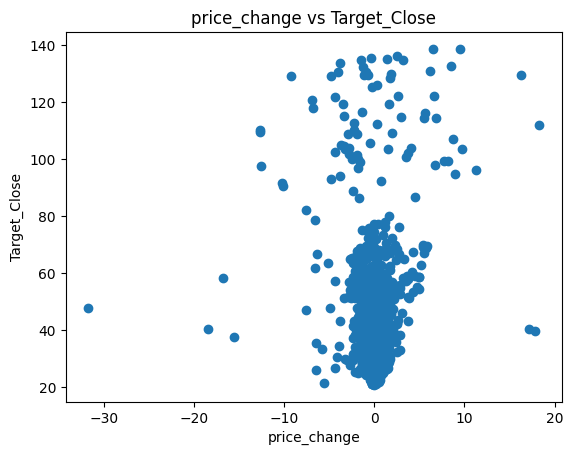

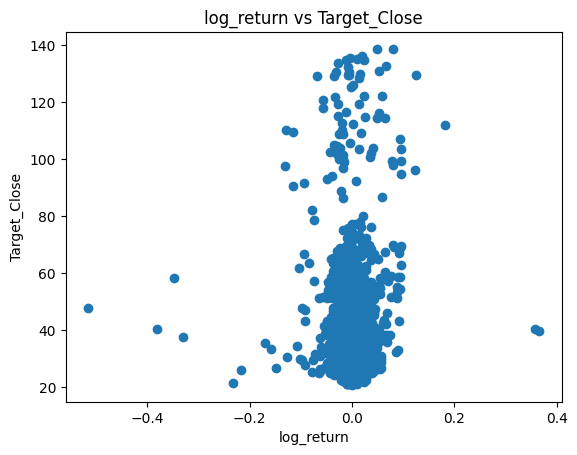

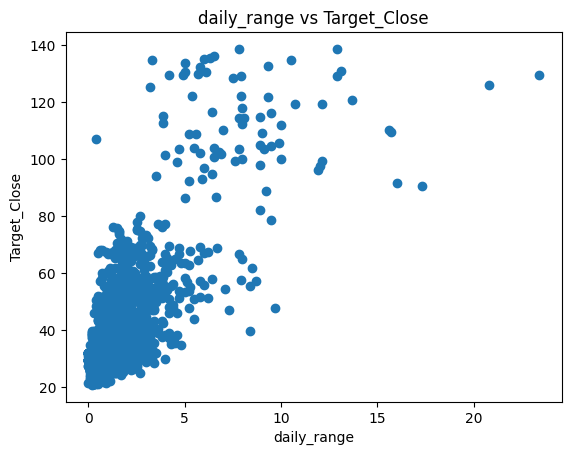

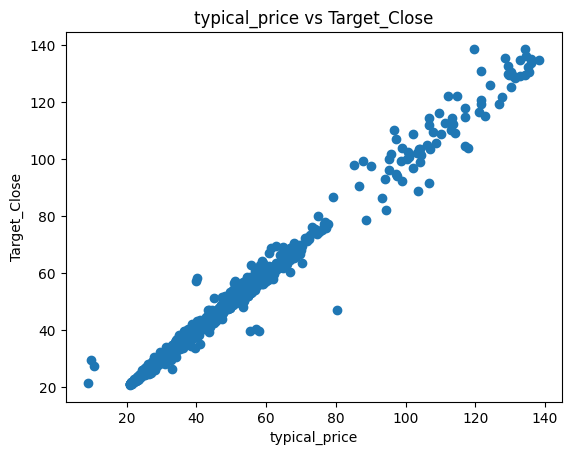

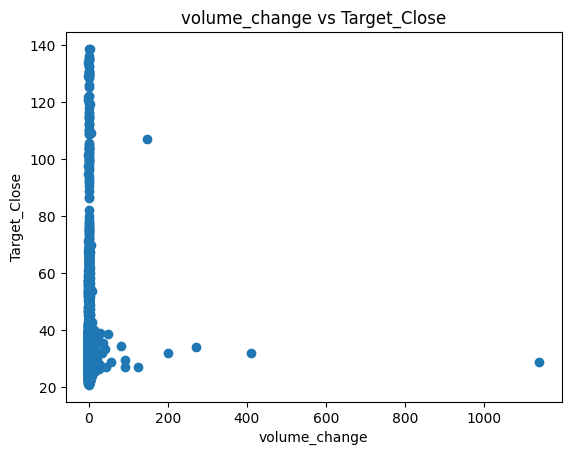

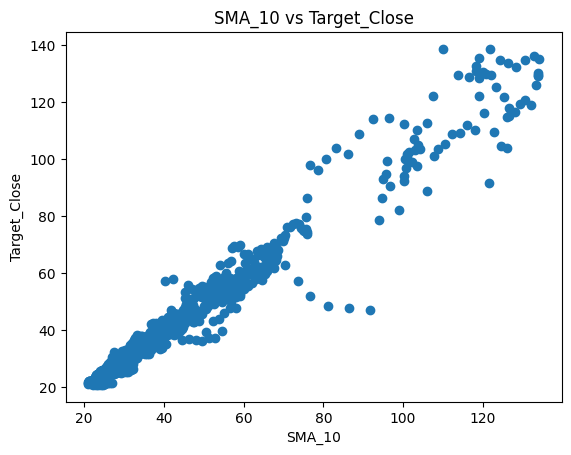

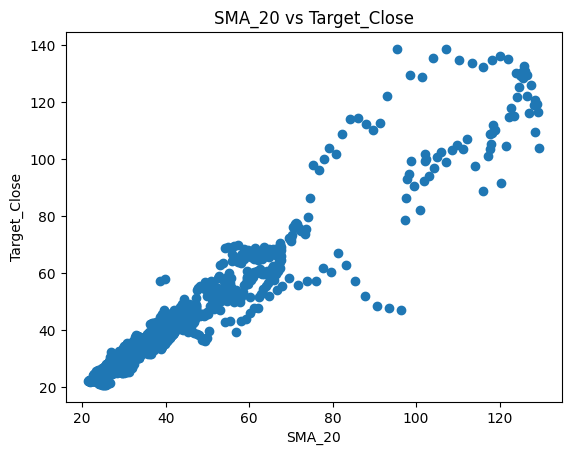

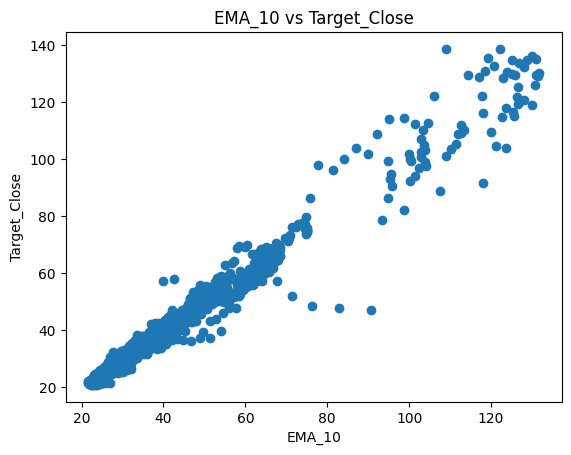

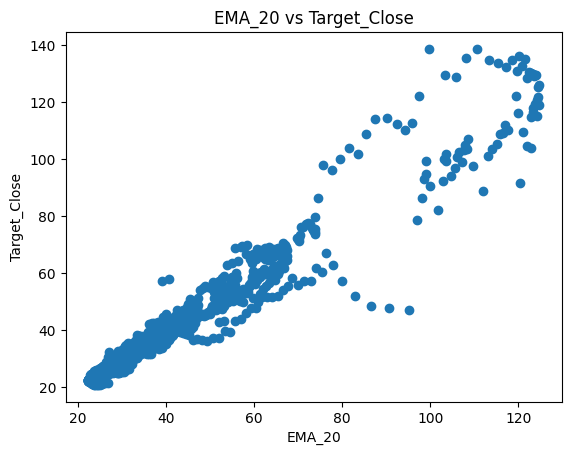

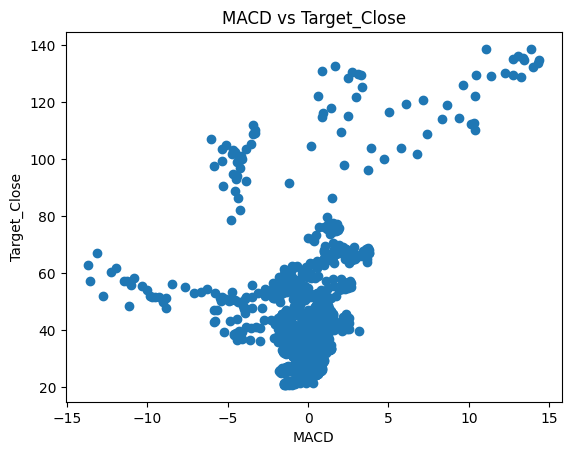

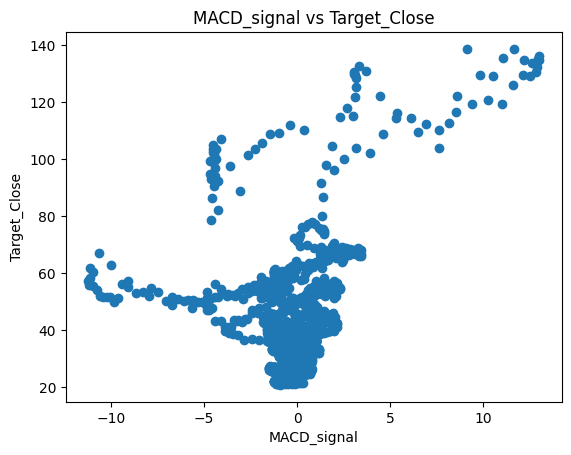

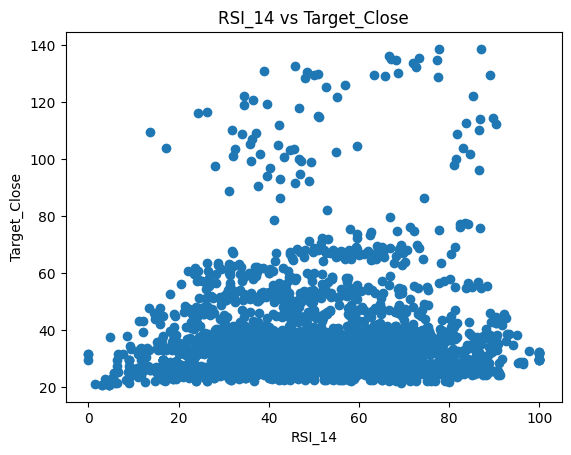

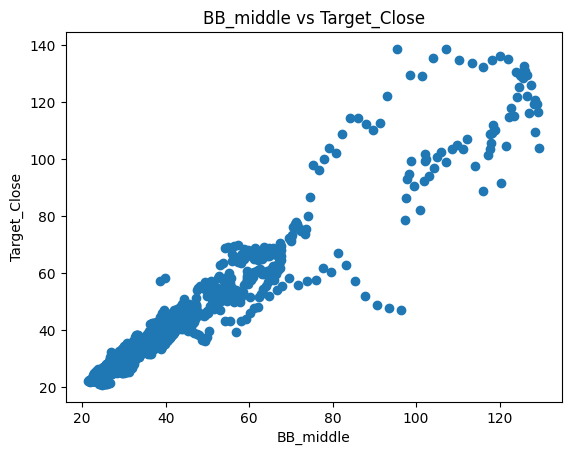

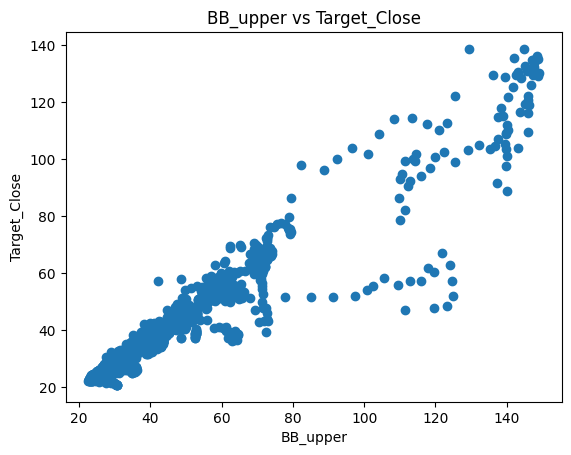

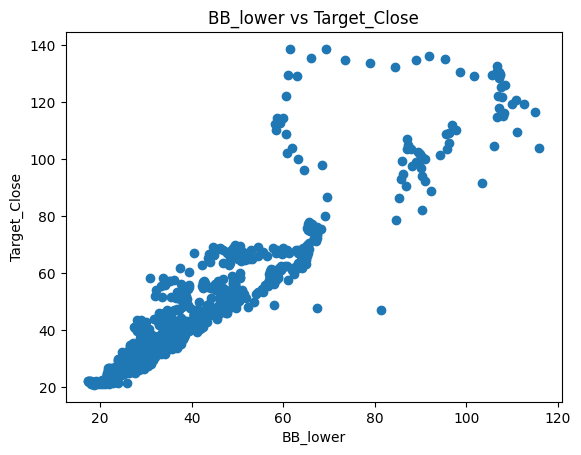

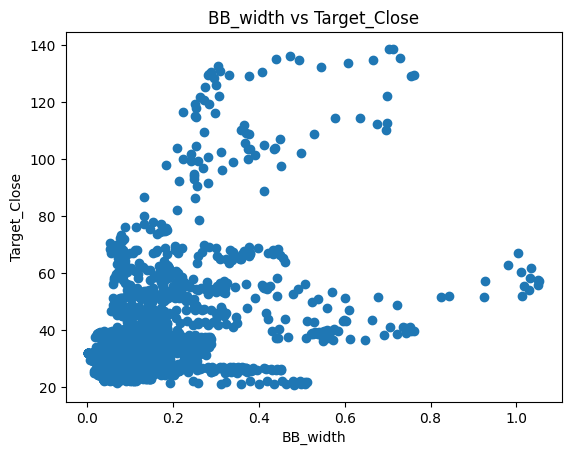

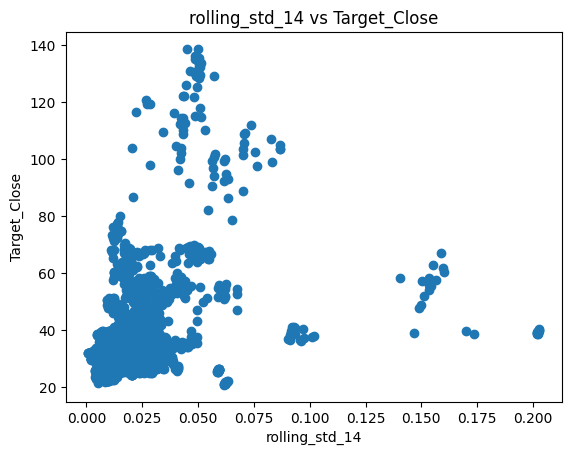

In [ ]:
# ================================
# SELECT NUMERIC FEATURES
# ================================
numeric_features = df_final.select_dtypes(include='number').columns.tolist()

# Remove target from feature list
numeric_features.remove('Target_Close')

# ================================
# SCATTER DIAGRAMS
# ================================
for feature in numeric_features:
    plt.figure()
    plt.scatter(df_final[feature], df_final['Target_Close'])
    plt.xlabel(feature)
    plt.ylabel("Target_Close")
    plt.title(f"{feature} vs Target_Close")
    plt.show()

Create a dataset where only high correlated features only name as : **df_selected**

In [ ]:
import pandas as pd

# ============================================
# FEATURE SELECTION (CORRELATION-BASED)
# ============================================
# -----------------------------
# Selected features based on correlation analysis
# -----------------------------
selected_features = [
    'Close',
    'typical_price',
    'High',
    'Low',
    'Open',
    'EMA_10',
    'SMA_10',
    'EMA_20',
    'SMA_20',
    'BB_middle',
    'BB_upper',
    'BB_lower'
]

target_column = 'Target_Close'

# -----------------------------
# Create selected-feature dataset
# -----------------------------
df_selected = df_final[selected_features + [target_column]].copy()

# -----------------------------
# Save selected-feature dataset
# -----------------------------
df_selected.to_csv(
    "/content/drive/MyDrive/0Thesis Dataset/ebl/EBL_selected_features.csv",
    index=False,
    lineterminator="\r\n"
)

print("Feature selection completed successfully")
print(f" Selected features: {len(selected_features)}")
print(" Saved as: EBL_selected_features.csv")


Feature selection completed successfully
 Selected features: 12
 Saved as: EBL_selected_features.csv


**Correlation Heat Map**

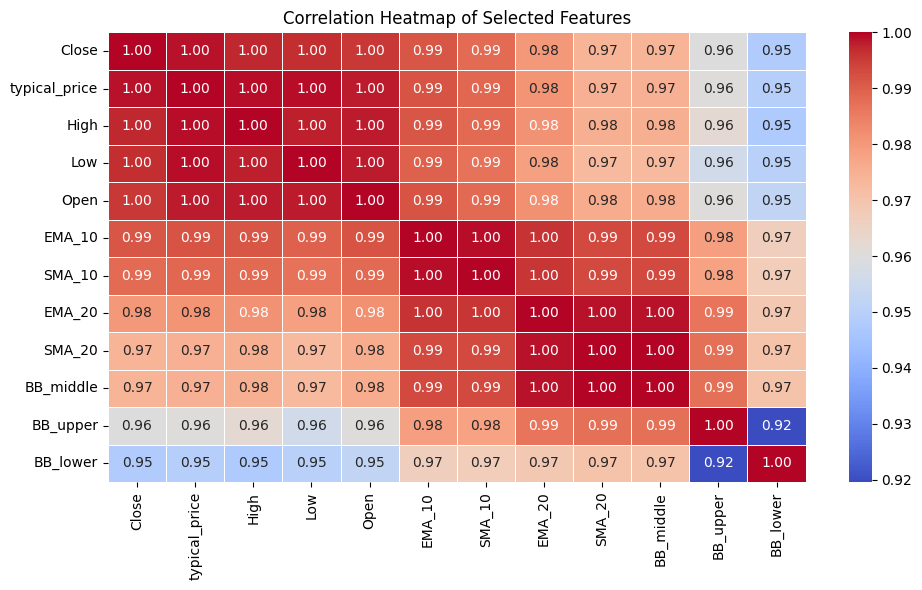

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# SELECTED FEATURES
# ================================
selected_features = [
    'Close',
    'typical_price',
    'High',
    'Low',
    'Open',
    'EMA_10',
    'SMA_10',
    'EMA_20',
    'SMA_20',
    'BB_middle',
    'BB_upper',
    'BB_lower'
]

# ================================
# CORRELATION HEATMAP
# ================================
plt.figure(figsize=(10, 6))

sns.heatmap(
    df_selected[selected_features].corr(),
    cmap='coolwarm',
    annot=True,        # show values (good for thesis)
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

In [ ]:
df_selected.head()

,Close,typical_price,High,Low,Open,EMA_10,SMA_10,EMA_20,SMA_20,BB_middle,BB_upper,BB_lower,Target_Close
0,72.0,71.166667,72.3,69.2,71.2,69.769824,69.28,69.695648,69.580,69.580,72.347176,66.812824,72.2
1,72.2,72.300000,73.2,71.5,72.9,70.211674,69.56,69.934158,69.690,69.690,72.692385,66.687615,71.9
2,71.9,71.833333,72.8,70.8,72.8,70.518642,69.88,70.121381,69.935,69.935,72.810138,67.059862,71.2
3,71.2,71.400000,72.9,70.1,70.1,70.642525,70.13,70.224107,70.125,70.125,72.789286,67.460714,72.2
4,72.2,72.600000,74.3,71.3,71.3,70.925703,70.44,70.412287,70.265,70.265,73.059939,67.470061,73.4


In [ ]:
df_selected.describe()

,Close,typical_price,High,Low,Open,EMA_10,SMA_10,EMA_20,SMA_20,BB_middle,BB_upper,BB_lower,Target_Close
count,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000,3203.000000
mean,36.150265,36.156239,36.767125,35.551327,36.159881,36.209795,36.209897,36.274835,36.275958,36.275958,39.138000,33.413917,36.136185
std,15.680098,15.746107,16.400971,15.199700,15.864561,15.559341,15.612485,15.433258,15.557310,15.557310,19.175956,12.554769,15.668103
min,20.800000,9.000000,0.000000,0.000000,0.000000,21.647999,21.040000,22.347710,21.505000,21.505000,22.585887,17.462588,20.800000
25%,27.200000,27.183333,27.600000,26.800000,27.050000,27.325877,27.290000,27.389606,27.335000,27.335000,28.982752,25.869059,27.200000
50%,32.200000,32.166667,32.600000,31.800000,32.100000,32.226960,32.210000,32.290702,32.255000,32.255000,33.937646,30.322254,32.200000
75%,38.100000,38.100000,38.600000,37.500000,38.200000,38.166833,38.115000,38.210256,38.212500,38.212500,40.182749,36.022248,38.100000
max,138.600000,138.366667,144.000000,134.000000,140.000000,131.755117,134.180000,124.773600,129.485000,129.485000,149.150509,115.910988,138.600000


Split the dataset(time based split):


*   ✔ Train → past (0-80)
*   ✔ Validation → future (but not latest) (80-90)
*   ✔ Test → latest unseen data (90-100)

using **standardscaler** this is best for timeseries datatype. also center of the data is 0 that's why i choose this.

In [ ]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Separate features and target
# -----------------------------
X = df_selected.drop(columns=['Target_Close'])
y = df_selected['Target_Close']

n = len(df_selected)

# -----------------------------
# Index boundaries
# -----------------------------
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

# -----------------------------
# Chronological split
# -----------------------------
X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

# -----------------------------
# Scaling (FIT ON TRAIN ONLY)
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# -----------------------------
# Sanity check
# -----------------------------
print(f"Train: {len(X_train_scaled)} ({len(X_train_scaled)/n*100:.1f}%)")
print(f"Val  : {len(X_val_scaled)} ({len(X_val_scaled)/n*100:.1f}%)")
print(f"Test : {len(X_test_scaled)} ({len(X_test_scaled)/n*100:.1f}%)")


Train: 2562 (80.0%)
Val  : 320 (10.0%)
Test : 321 (10.0%)


**Check scaling **


--- Scaling Check ---
Train mean (first 5): [ 1.55309888e-16 -2.21871268e-17  5.32491043e-16 -3.32806902e-16
  1.10935634e-16]
Train std  (first 5): [1. 1. 1. 1. 1.]

Val mean (first 5): [-0.56207181 -0.56861529 -0.57575942 -0.56664553 -0.56668246]
Val std  (first 5): [0.1767103  0.19730352 0.21478735 0.23236503 0.22160061]

Test mean (first 5): [-0.84182633 -0.84426038 -0.84147105 -0.84827058 -0.83906933]
Test std  (first 5): [0.09814447 0.1094392  0.12318701 0.12934044 0.12538081]

NaN check (train): 0
Inf check (train): 0


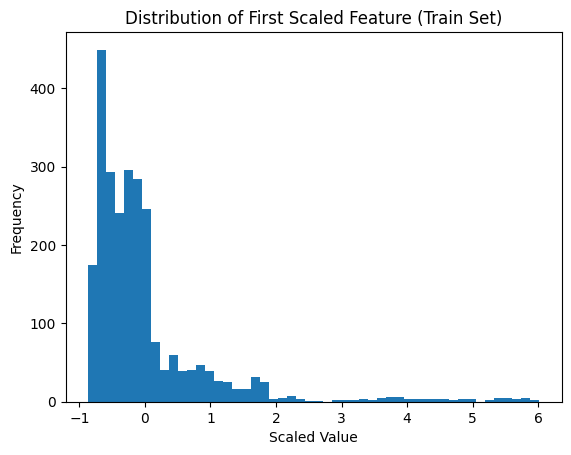


 Scaling verified successfully. Pipeline is correct.


In [ ]:
# ============================================
# 5. SCALING VERIFICATION
# ============================================
print("\n--- Scaling Check ---")

print("Train mean (first 5):", np.mean(X_train_scaled, axis=0)[:5])
print("Train std  (first 5):", np.std(X_train_scaled, axis=0)[:5])

print("\nVal mean (first 5):", np.mean(X_val_scaled, axis=0)[:5])
print("Val std  (first 5):", np.std(X_val_scaled, axis=0)[:5])

print("\nTest mean (first 5):", np.mean(X_test_scaled, axis=0)[:5])
print("Test std  (first 5):", np.std(X_test_scaled, axis=0)[:5])

# ============================================
# 6. NaN / INF CHECK
# ============================================
print("\nNaN check (train):", np.isnan(X_train_scaled).sum())
print("Inf check (train):", np.isinf(X_train_scaled).sum())

# ============================================
# 7. VISUAL CHECK
# ============================================
plt.figure()
plt.hist(X_train_scaled[:, 0], bins=50)
plt.title("Distribution of First Scaled Feature (Train Set)")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.show()

print("\n Scaling verified successfully. Pipeline is correct.")

# **Base line machine learning model like Regression, KNN and SVM**


Common Setup (Metrics & Imports)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} Results:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)

    return mae, rmse, r2

**Linear Regression (Baseline)**

In [ ]:
from sklearn.linear_model import LinearRegression

# Model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
evaluate_model(y_test, y_pred_lr, "Linear Regression")


Linear Regression Results:
MAE  : 0.2301
RMSE : 0.5665
R²   : 0.8809
------------------------------


(0.23005173540400387, np.float64(0.5665462119599666), 0.8809108453836851)

**Support Vector Regression (SVR)**


*   **SVR Perform well amoung those base line models**




In [ ]:
from sklearn.svm import SVR

# Model (RBF kernel is standard for finance)
svr_model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1,
    gamma='scale'
)

# Train
svr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate
evaluate_model(y_test, y_pred_svr, "Support Vector Regression (SVR)")


Support Vector Regression (SVR) Results:
MAE  : 0.4765
RMSE : 1.0893
R²   : 0.5598
------------------------------


(0.4765392574682497, np.float64(1.0892543723426953), 0.5597897446228552)

**K-Nearest Neighbors (KNN)**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Model
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance',
    metric='minkowski'
)

# Train
knn_model.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate
evaluate_model(y_test, y_pred_knn, "KNN Regression")


KNN Regression Results:
MAE  : 1.0121
RMSE : 1.3855
R²   : 0.2878
------------------------------


(1.0120799695899219, np.float64(1.3854849516958916), 0.28779477041009505)

**Ridge Regression (Tuning)**

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

best_alpha = None
best_rmse = float('inf')

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    y_val_pred = ridge.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    print(f"Alpha={alpha:<6} | Validation RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print("\n Best alpha selected:", best_alpha)


Alpha=0.001  | Validation RMSE=0.5839
Alpha=0.01   | Validation RMSE=0.5772
Alpha=0.1    | Validation RMSE=0.5192
Alpha=1      | Validation RMSE=0.3654
Alpha=10     | Validation RMSE=0.9268
Alpha=100    | Validation RMSE=1.2263

 Best alpha selected: 1


In [ ]:
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_train_scaled, y_train)

y_test_pred = ridge_final.predict(X_test_scaled)

evaluate_model(y_test, y_test_pred, "Tuned Ridge Regression")


Tuned Ridge Regression Results:
MAE  : 0.2157
RMSE : 0.3439
R²   : 0.9561
------------------------------


(0.21566084951837755, np.float64(0.34389212117598245), 0.9561220848531673)

# Hyperparameters for deep learning models

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, LSTM, GRU, Dropout,
    LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam

In [ ]:
# ================================
# GLOBAL HYPERPARAMETERS
# ================================

WINDOW_SIZE = 30          # sequence window length
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

# LSTM / GRU
RNN_UNITS = 64
RNN_DROPOUT = 0.2

# Transformer
NUM_HEADS = 4
TRANSFORMER_DIM = 64
FF_DIM = 128
TRANSFORMER_DROPOUT = 0.1

# Time2Vec
TIME2VEC_DIM = 8

**Sequence Windows**

In [ ]:
import numpy as np

def create_sequences(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, WINDOW_SIZE)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val.values, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, WINDOW_SIZE)

**LSTM Model**

In [ ]:
def build_lstm(input_shape):
    model = Sequential([
        LSTM(RNN_UNITS, return_sequences=False, input_shape=input_shape),
        Dropout(RNN_DROPOUT),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mse'
    )
    return model

lstm_model = build_lstm((WINDOW_SIZE, X_train_seq.shape[2]))
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

**GRU Model**

In [ ]:
def build_gru(input_shape):
    model = Sequential([
        GRU(RNN_UNITS, return_sequences=False, input_shape=input_shape),
        Dropout(RNN_DROPOUT),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mse'
    )
    return model

gru_model = build_gru((WINDOW_SIZE, X_train_seq.shape[2]))
gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,041 (58.75 KB)

 Trainable params: 15,041 (58.75 KB)

 Non-trainable params: 0 (0.00 B)

**Transformer Model**

**Time2Vec Layer (Custom)**

In [ ]:
class Time2Vec(tf.keras.layers.Layer):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size

    def build(self, input_shape):
        self.w = self.add_weight(
            name='weight',
            shape=(input_shape[-1], self.kernel_size),
            initializer='uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.kernel_size,),
            initializer='uniform',
            trainable=True
        )

    def call(self, inputs):
        v = tf.linalg.matmul(inputs, self.w) + self.b
        return tf.concat([inputs, tf.math.sin(v)], axis=-1)

**Transformer Encoder only + Time2Vec Model**

In [ ]:
def build_transformer(input_shape):
    inputs = Input(shape=input_shape)

    # Time2Vec Encoding
    t2v = Time2Vec(TIME2VEC_DIM)(inputs)

    # Self-Attention
    attn_output = MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=TRANSFORMER_DIM
    )(t2v, t2v)

    attn_output = Dropout(TRANSFORMER_DROPOUT)(attn_output)
    out1 = LayerNormalization()(t2v + attn_output)

    # Feed Forward Network
    ffn = Dense(FF_DIM, activation='relu')(out1)
    ffn = Dense(out1.shape[-1])(ffn)

    out2 = LayerNormalization()(out1 + ffn)

    # KERAS-SAFE pooling (FIX)
    x = GlobalAveragePooling1D()(out2)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='mse'
    )

    return model
transformer_model = build_transformer(
    (WINDOW_SIZE, X_train_seq.shape[2])
)

transformer_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vec           │ (None, 30, 20)    │        104 │ input_layer_2[0]… │
│ (Time2Vec)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 20)    │     21,268 │ time2_vec[0][0],  │
│ (MultiHeadAttentio… │                   │            │ time2_vec[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 20)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 20)    │          0 │ time2_vec[0][0],  │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 20)    │         40 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │      2,688 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 20)    │      2,580 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 20)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 20)    │         40 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 20)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         21 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,741 (104.46 KB)

 Trainable params: 26,741 (104.46 KB)

 Non-trainable params: 0 (0.00 B)

Train Any Model (Reusable)

In [ ]:
def train_model(model, name):
    print(f"\nTraining {name}...")
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    return history

Train Models

In [ ]:
train_model(lstm_model, "LSTM")
train_model(gru_model, "GRU")
train_model(transformer_model, "Transformer + Time2Vec")


Training LSTM...
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1283.9869 - val_loss: 259.5432
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 732.9822 - val_loss: 104.5543
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 532.9998 - val_loss: 37.2382
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 415.8455 - val_loss: 11.0053
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 342.6327 - val_loss: 9.0919
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 301.6470 - val_loss: 19.2333
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 275.6184 - val_loss: 34.1110
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 262.0076 - val_loss: 50.4251
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 258.0072 - val_loss: 62.9674
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 257.7759 - val_loss: 72.1560
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 254.4822 - val_loss: 67.8959
Epoch 12/50
80/80 

**Evaluate (MAE, RMSE, R²)**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_dl(model, name):
    y_pred = model.predict(X_test_seq).flatten()

    mae = mean_absolute_error(y_test_seq, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
    r2 = r2_score(y_test_seq, y_pred)

    print(f"\n{name} Results:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

evaluate_dl(lstm_model, "LSTM")
evaluate_dl(gru_model, "GRU")
evaluate_dl(transformer_model, "Transformer + Time2Vec")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

LSTM Results:
MAE  : 0.6033
RMSE : 0.8419
R²   : 0.7528
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

GRU Results:
MAE  : 0.7646
RMSE : 0.9870
R²   : 0.6603
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step

Transformer + Time2Vec Results:
MAE  : 0.7447
RMSE : 0.9849
R²   : 0.6617


# Diagram for predicted and actual

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def plot_actual_vs_predicted(
    y_true,
    y_pred,
    model_name,
    num_points=200
):
    """
    Plot Actual vs Predicted prices

    y_true     : actual prices
    y_pred     : predicted prices
    model_name : name of the model (string)
    num_points : number of last points to plot
    """

    plt.figure(figsize=(12, 4))

    plt.plot(
        y_true[-num_points:],
        label="Actual Price",
        linewidth=2
    )

    plt.plot(
        y_pred[-num_points:],
        label="Predicted Price",
        linestyle="--"
    )

    plt.title(f"{model_name} – Actual vs Predicted Closing Price")
    plt.xlabel("Time Index")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.grid(True)
    plt.show()

SVR

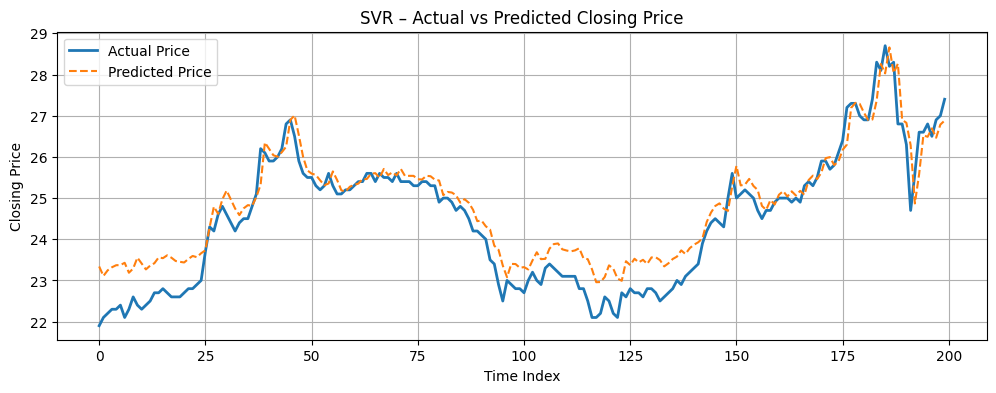

In [ ]:
y_pred_svr = svr_model.predict(X_test_scaled)

plot_actual_vs_predicted(
    y_true=y_test.values,
    y_pred=y_pred_svr,
    model_name="SVR"
)

Linear Regression

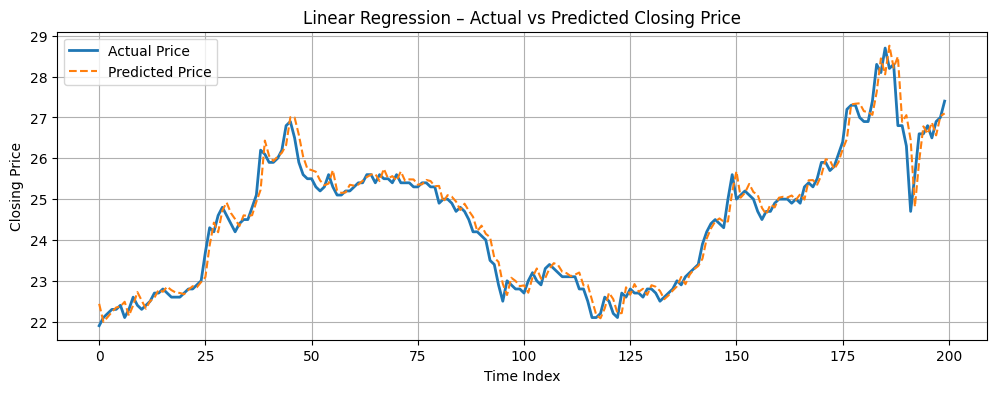

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)

plot_actual_vs_predicted(
    y_true=y_test.values,
    y_pred=y_pred_lr,
    model_name="Linear Regression"
)

Ridge Regression

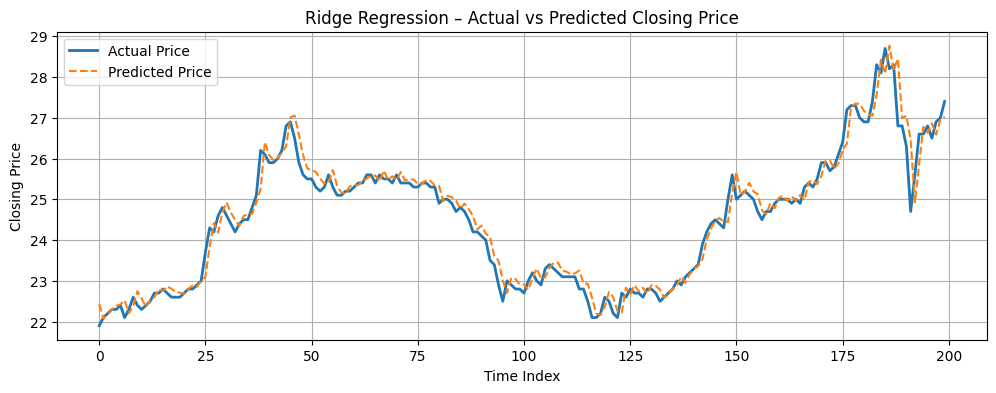

In [ ]:
y_pred_ridge = ridge_final.predict(X_test_scaled)

plot_actual_vs_predicted(
    y_true=y_test.values,
    y_pred=y_pred_ridge,
    model_name="Ridge Regression"
)

LSTM

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


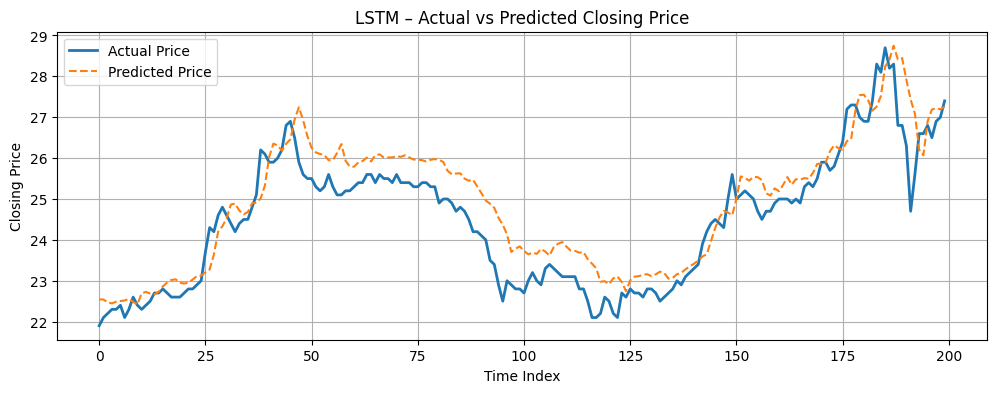

In [ ]:
y_pred_lstm = lstm_model.predict(X_test_seq).flatten()

plot_actual_vs_predicted(
    y_true=y_test_seq,
    y_pred=y_pred_lstm,
    model_name="LSTM"
)

GRU

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


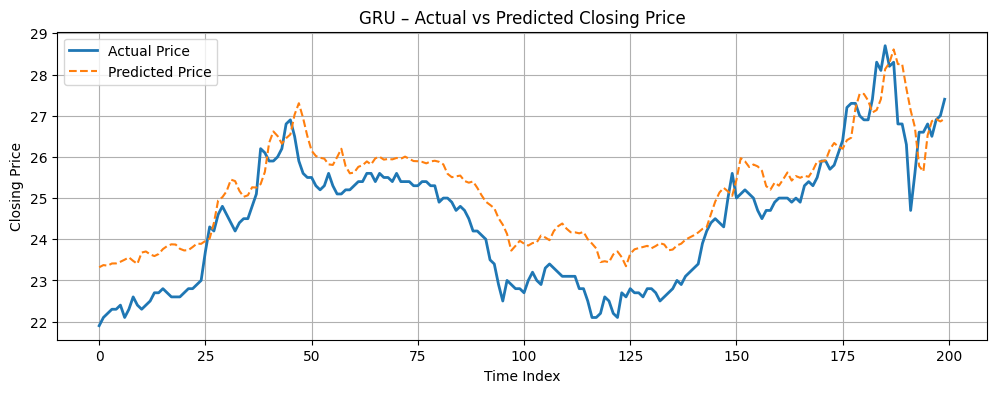

In [ ]:
y_pred_gru = gru_model.predict(X_test_seq).flatten()

plot_actual_vs_predicted(
    y_true=y_test_seq,
    y_pred=y_pred_gru,
    model_name="GRU"
)

Transformer

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


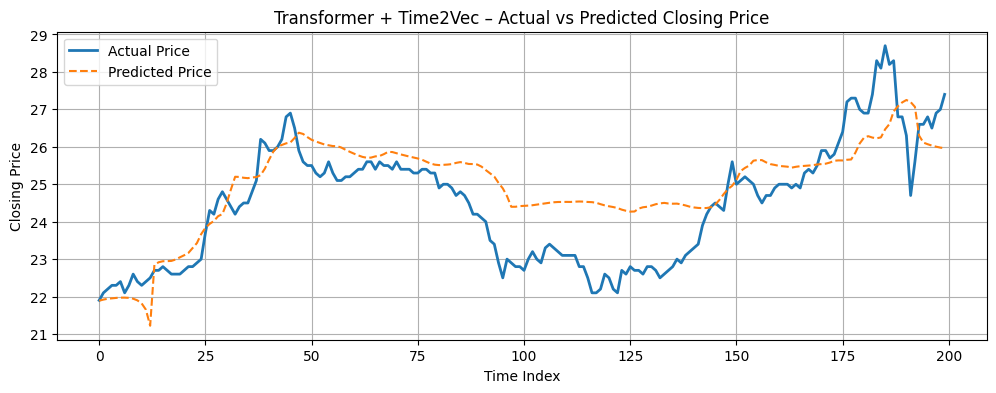

In [ ]:
y_pred_transformer = transformer_model.predict(X_test_seq).flatten()

plot_actual_vs_predicted(
    y_true=y_test_seq,
    y_pred=y_pred_transformer,
    model_name="Transformer + Time2Vec"
)


ALL together deep learning models

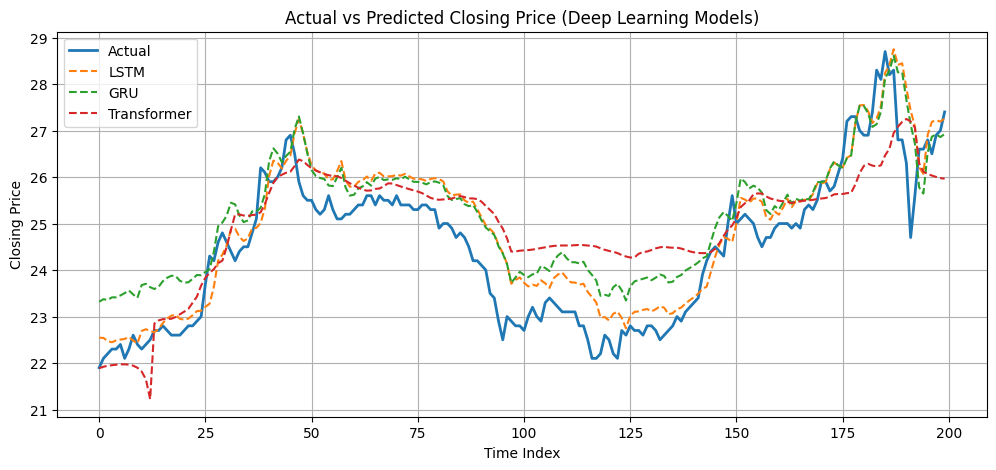

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_seq[-200:], label="Actual", linewidth=2)
plt.plot(y_pred_lstm[-200:], "--", label="LSTM")
plt.plot(y_pred_gru[-200:], "--", label="GRU")
plt.plot(y_pred_transformer[-200:], "--", label="Transformer")

plt.title("Actual vs Predicted Closing Price (Deep Learning Models)")
plt.xlabel("Time Index")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

**Model Comparison Bar chart**

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


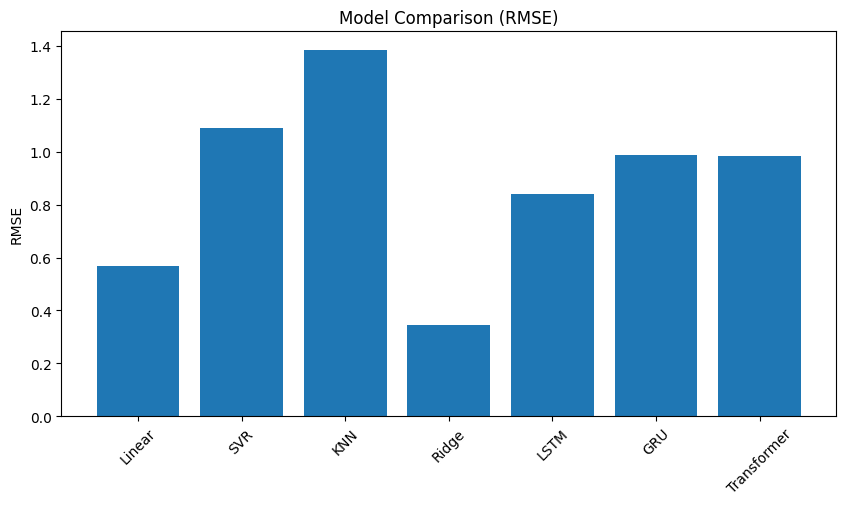

In [ ]:
# ================================
# MODEL COMPARISON (RMSE)
# ================================

models = ["Linear", "SVR", "KNN", "Ridge", "LSTM", "GRU", "Transformer"]

rmse_values = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    np.sqrt(mean_squared_error(y_test, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),  # ridge
    np.sqrt(mean_squared_error(y_test_seq, lstm_model.predict(X_test_seq).flatten())),
    np.sqrt(mean_squared_error(y_test_seq, gru_model.predict(X_test_seq).flatten())),
    np.sqrt(mean_squared_error(y_test_seq, transformer_model.predict(X_test_seq).flatten()))
]

plt.figure(figsize=(10, 5))
plt.bar(models, rmse_values)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


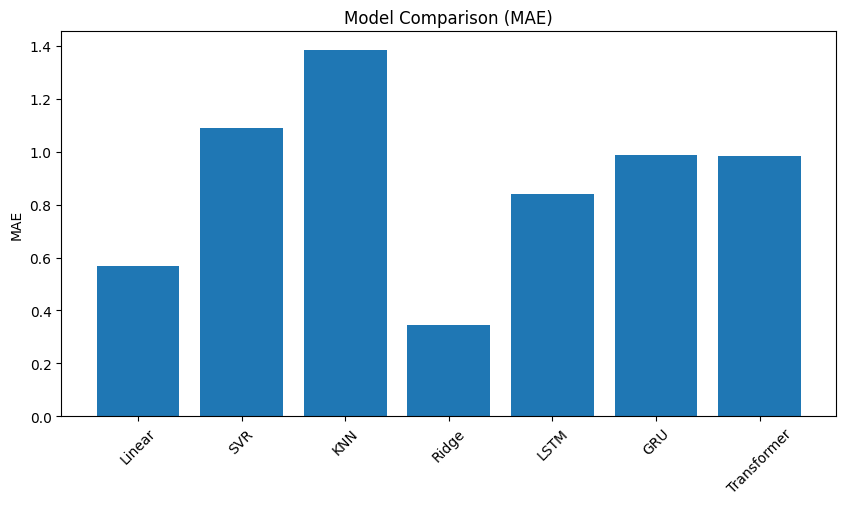

In [ ]:
# ================================
# MODEL COMPARISON (MAE)
# ================================

models = ["Linear", "SVR", "KNN", "Ridge", "LSTM", "GRU", "Transformer"]

rmse_values = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    np.sqrt(mean_squared_error(y_test, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),  # ridge
    np.sqrt(mean_squared_error(y_test_seq, lstm_model.predict(X_test_seq).flatten())),
    np.sqrt(mean_squared_error(y_test_seq, gru_model.predict(X_test_seq).flatten())),
    np.sqrt(mean_squared_error(y_test_seq, transformer_model.predict(X_test_seq).flatten()))
]

plt.figure(figsize=(10, 5))
plt.bar(models, rmse_values)
plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


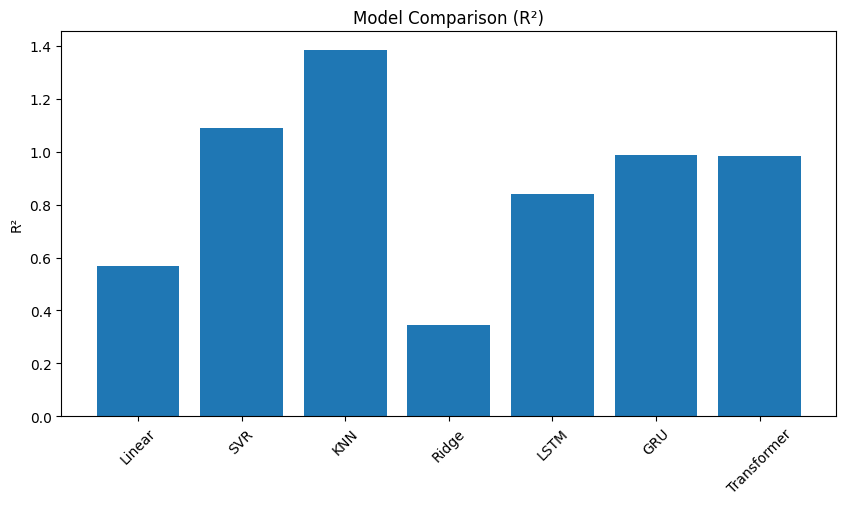

In [ ]:
# ================================
# MODEL COMPARISON (R²)
# ================================

models = ["Linear", "SVR", "KNN", "Ridge", "LSTM", "GRU", "Transformer"]

rmse_values = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    np.sqrt(mean_squared_error(y_test, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test, y_test_pred)),  # ridge
    np.sqrt(mean_squared_error(y_test_seq, lstm_model.predict(X_test_seq).flatten())),
    np.sqrt(mean_squared_error(y_test_seq, gru_model.predict(X_test_seq).flatten())),
    np.sqrt(mean_squared_error(y_test_seq, transformer_model.predict(X_test_seq).flatten()))
]

plt.figure(figsize=(10, 5))
plt.bar(models, rmse_values)
plt.title("Model Comparison (R²)")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()